## Análise de Entropia (Entre 1 e 0)

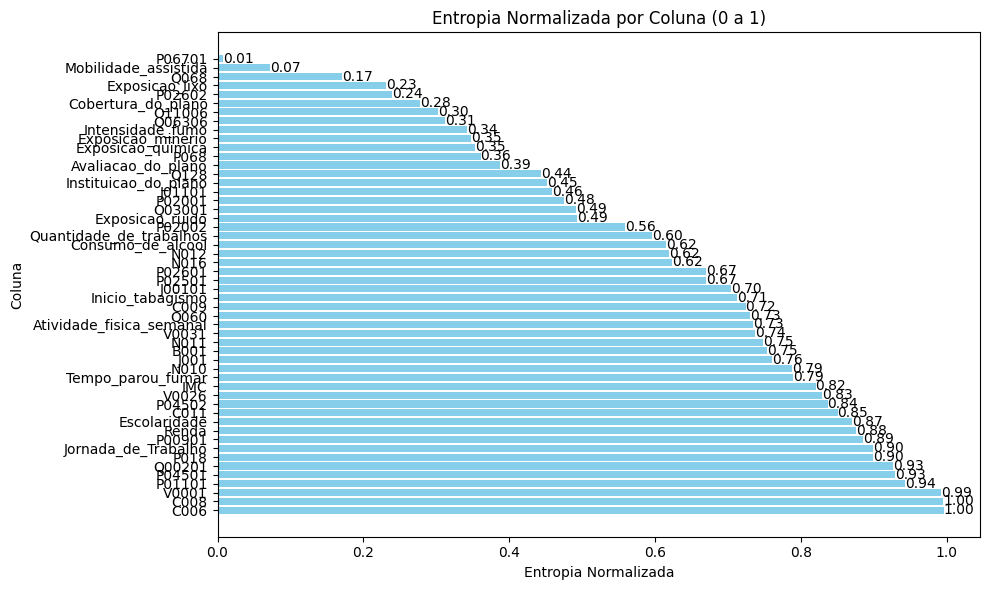


Resultados da Análise de Entropia Normalizada:
                  Coluna  Entropia Normalizada (0-1)  Entropia Bruta (bits)  Valores Únicos Tipo de Dado
                    C006                    0.995639               0.995639               2      float64
                    C008                    0.995258               4.930704              31      float64
                   V0001                    0.992063               3.671069              13        int64
                  P01101                    0.943057               2.829170               8      float64
                  P04501                    0.929349               2.402332               6      float64
                  Q00201                    0.925811               0.925811               2      float64
                    P018                    0.898589               2.695766               8      float64
     Jornada_de_Trabalho                    0.898561               1.424186               3        int64
       

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def calcular_entropia_normalizada(coluna, base=2):
    """
    Calcula a entropia de Shannon normalizada (0 a 1) de uma coluna do DataFrame.
    
    Parâmetros:
    coluna (pd.Series): Coluna do DataFrame a ser analisada
    base (int): Base do logaritmo (2 para bits)
    
    Retorna:
    float: Valor da entropia normalizada entre 0 e 1
    """
    # Conta a frequência de cada valor único
    contador = Counter(coluna.dropna())  # Remove valores nulos
    total = len(coluna.dropna())
    
    if total == 0:
        return 0.0
    
    # Calcula as probabilidades
    probabilidades = np.array([contador[x]/total for x in contador])
    
    # Remove probabilidades zero para evitar problemas com log
    probabilidades = probabilidades[probabilidades > 0]
    
    # Calcula a entropia
    entropia = -np.sum(probabilidades * np.log(probabilidades)) / np.log(base)
    
    # Calcula a entropia máxima possível (log(N) na base 2)
    N = len(contador)
    if N <= 1:
        return 0.0  # Evita divisão por zero para coluna constante
    
    entropia_maxima = np.log(N) / np.log(base)
    
    # Normaliza a entropia entre 0 e 1
    entropia_normalizada = entropia / entropia_maxima
    
    return entropia_normalizada

def analisar_entropia_dataframe(df):
    """
    Analisa a entropia normalizada de todas as colunas de um DataFrame.
    
    Parâmetros:
    df (pd.DataFrame): DataFrame a ser analisado
    
    Retorna:
    pd.DataFrame: DataFrame com os resultados de entropia normalizada
    """
    resultados = []
    
    for coluna in df.columns:
        # Calcula entropia normalizada para cada coluna
        entropia_norm = calcular_entropia_normalizada(df[coluna])
        
        # Calcula também a entropia bruta para referência
        entropia_bruta = calcular_entropia_normalizada(df[coluna]) * (np.log(df[coluna].nunique()) / np.log(2)) if df[coluna].nunique() > 1 else 0
        
        # Conta valores únicos
        valores_unicos = df[coluna].nunique()
        
        # Adiciona aos resultados
        resultados.append({
            'Coluna': coluna,
            'Entropia Normalizada (0-1)': entropia_norm,
            'Entropia Bruta (bits)': entropia_bruta,
            'Valores Únicos': valores_unicos,
            'Tipo de Dado': df[coluna].dtype
        })
    
    # Cria DataFrame de resultados
    df_resultados = pd.DataFrame(resultados)
    
    # Ordena por entropia decrescente
    df_resultados = df_resultados.sort_values('Entropia Normalizada (0-1)', ascending=False)
    
    # Plota gráfico de entropia
    plt.figure(figsize=(10, 6))
    bars = plt.barh(df_resultados['Coluna'], df_resultados['Entropia Normalizada (0-1)'], 
    
    
    ='skyblue')
    plt.title('Entropia Normalizada por Coluna (0 a 1)')
    plt.xlabel('Entropia Normalizada')
    plt.ylabel('Coluna')
    
    # Adiciona valores nas barras
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.2f}', 
                ha='left', va='center')
    
    plt.tight_layout()
    plt.show()
    
    return df_resultados

# Carrega seus dados
df = pd.read_csv("../Bases/Criados/5_base_codificada.csv")

# Analisa a entropia normalizada
resultados_entropia = analisar_entropia_dataframe(df)

# Mostra os resultados
print("\nResultados da Análise de Entropia Normalizada:")
print(resultados_entropia.to_string(index=False))

# Salva os resultados em CSV se desejar
# resultados_entropia.to_csv("resultados_entropia_normalizada.csv", index=False)

## Análise de Entropia (Partindo de 0)

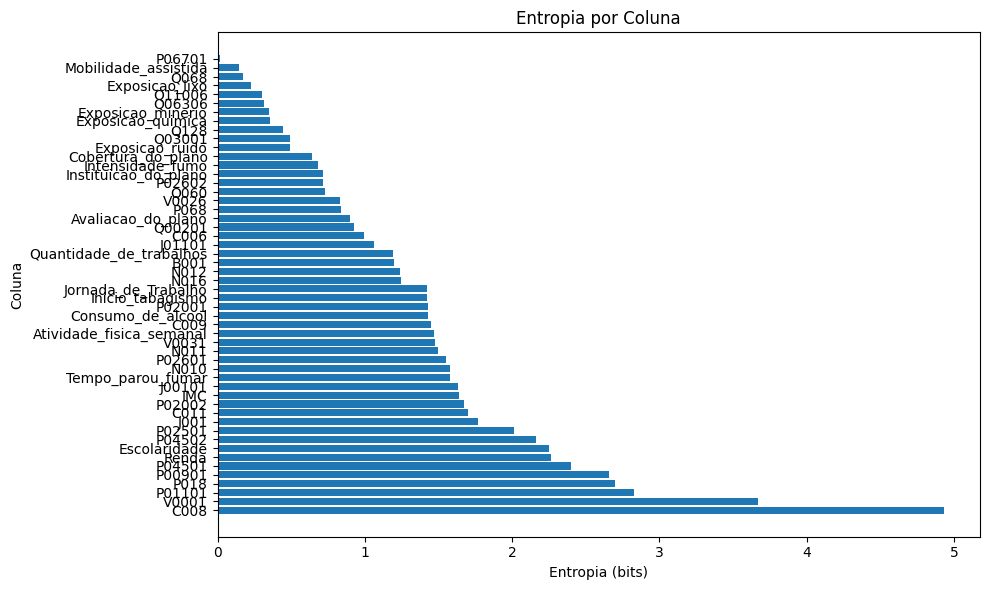


Resultados da Análise de Entropia:
                      Coluna  Entropia  Valores Únicos Tipo de Dado
5                       C008  4.930704              31      float64
0                      V0001  3.671069              13        int64
16                    P01101  2.829170               8      float64
18                      P018  2.695766               8      float64
15                    P00901  2.656667               8      float64
23                    P04501  2.402332               6      float64
35                     Renda  2.264274               6        int64
34              Escolaridade  2.248265               6        int64
24                    P04502  2.162007               6      float64
20                    P02501  2.010841               8      float64
8                       J001  1.766127               5      float64
7                       C011  1.700324               4      float64
19                    P02002  1.676940               8      float64
51          

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def calcular_entropia(coluna, base=2):
    """
    Calcula a entropia de Shannon de uma coluna do DataFrame.
    
    Parâmetros:
    coluna (pd.Series): Coluna do DataFrame a ser analisada
    base (int): Base do logaritmo (2 para bits, e para nats, 10 para bans)
    
    Retorna:
    float: Valor da entropia
    """
    # Conta a frequência de cada valor único
    contador = Counter(coluna.dropna())  # Remove valores nulos
    total = len(coluna.dropna())
    
    if total == 0:
        return 0.0
    
    # Calcula as probabilidades
    probabilidades = np.array([contador[x]/total for x in contador])
    
    # Remove probabilidades zero para evitar problemas com log
    probabilidades = probabilidades[probabilidades > 0]
    
    # Calcula a entropia
    entropia = -np.sum(probabilidades * np.log(probabilidades)) / np.log(base)
    
    return entropia

def analisar_entropia_dataframe(df):
    """
    Analisa a entropia de todas as colunas de um DataFrame.
    
    Parâmetros:
    df (pd.DataFrame): DataFrame a ser analisado
    
    Retorna:
    pd.DataFrame: DataFrame com os resultados de entropia
    """
    resultados = []
    
    for coluna in df.columns:
        # Calcula entropia para cada coluna
        entropia = calcular_entropia(df[coluna])
        
        # Conta valores únicos
        valores_unicos = df[coluna].nunique()
        
        # Adiciona aos resultados
        resultados.append({
            'Coluna': coluna,
            'Entropia': entropia,
            'Valores Únicos': valores_unicos,
            'Tipo de Dado': df[coluna].dtype
        })
    
    # Cria DataFrame de resultados
    df_resultados = pd.DataFrame(resultados)
    
    # Ordena por entropia decrescente
    df_resultados = df_resultados.sort_values('Entropia', ascending=False)
    
    # Plota gráfico de entropia
    plt.figure(figsize=(10, 6))
    plt.barh(df_resultados['Coluna'], df_resultados['Entropia'])
    plt.title('Entropia por Coluna')
    plt.xlabel('Entropia (bits)')
    plt.ylabel('Coluna')
    plt.tight_layout()
    plt.show()
    
    return df_resultados

# Carrega seus dados
df = pd.read_csv("../Bases/Criados/5_base_codificada.csv")

# Analisa a entropia
resultados_entropia = analisar_entropia_dataframe(df)

# Mostra os resultados
print("\nResultados da Análise de Entropia:")
print(resultados_entropia)

# Salva os resultados em CSV se desejar
# resultados_entropia.to_csv("resultados_entropia.csv", index=False)

## Análise de Entropia (Código do Daniel)

In [17]:
import pandas as pd
from scipy.stats import entropy

entropyDict = {}
def calculate_entropy_using_scipy(column):
    counts = column.value_counts()
    probabilities = counts / counts.sum()
    return entropy(probabilities, base=2)

for i in df.columns:
    entropy_value = calculate_entropy_using_scipy(df[i])
    print("Entropia da coluna "+i+" :"+str(entropy_value))
    entropyDict[str(i)] =  entropy_value

entropyDictSortedDecre = sorted(entropyDict, key=entropyDict.get, reverse=True)
for i in entropyDictSortedDecre:
    print("Entropia da coluna "+i+" :"+str(entropyDict[i]))

entropyDictSortedCre = sorted(entropyDict, key=entropyDict.get, reverse=False)
for i in entropyDictSortedCre:
    print("Entropia da coluna "+i+" :"+str(entropyDict[i]))

Entropia da coluna V0001 :3.671068763523479
Entropia da coluna V0026 :0.8293309256498449
Entropia da coluna V0031 :1.4742764919941553
Entropia da coluna B001 :1.1951355017091934
Entropia da coluna C006 :0.9956393753946406
Entropia da coluna C008 :4.93070353046933
Entropia da coluna C009 :1.4480293057453641
Entropia da coluna C011 :1.7003237677510779
Entropia da coluna J001 :1.7661271750047505
Entropia da coluna J00101 :1.6344157774646564
Entropia da coluna J01101 :1.0653551523485028
Entropia da coluna N010 :1.5765446445261073
Entropia da coluna N011 :1.4966522036618368
Entropia da coluna N012 :1.2377552925620867
Entropia da coluna N016 :1.246768743854175
Entropia da coluna P00901 :2.6566668069172907
Entropia da coluna P01101 :2.829170032646085
Entropia da coluna P02001 :1.4258902495767813
Entropia da coluna P018 :2.695765503598288
Entropia da coluna P02002 :1.6769399870322563
Entropia da coluna P02501 :2.0108407091995764
Entropia da coluna P02602 :0.719045559081399
Entropia da coluna P